# Requirements

In [7]:
!pip install yfinance

In [8]:
!pip install pandas_datareader

In [9]:
import yfinance as yf
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [10]:
from IPython.display import display, HTML
import builtins
import sys

In [11]:
import pandas_datareader.data as pdr

In [12]:
def make_sequences(scaled_df, seq_length=20):
    X, y = [], []
    arr = scaled_df.values
    t_idx = feature_cols.index(target_col)
    for i in range(len(arr) - seq_length):
        X.append(arr[i:i+seq_length, :])
        y.append(arr[i+seq_length, t_idx])
    return torch.tensor(np.array(X), dtype=torch.float32), torch.tensor(np.array(y), dtype=torch.float32)

In [13]:
def mc_dropout_prediction(model, X, n_iter=100):
    model.train() # Mantener dropout activo para variar las predicciones
    preds = []
    with torch.no_grad():
        for _ in range(n_iter):
            pred = model(X.to(device)).squeeze().cpu().numpy()
            preds.append(pred)
    preds = np.array(preds)
    return preds.mean(axis=0), preds.std(axis=0)


# Enviroment

In [14]:
np.random.seed(1984)
torch.manual_seed(1984)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Data Upload

In [15]:
start="2018-01-01"
end="2026-03-03"

In [33]:
# A) Expedia Prices
px = yf.download("EXPE", start=start, end=end, auto_adjust=False)
if isinstance(px.columns, pd.MultiIndex):
    px.columns = px.columns.get_level_values(0)

px = px.rename(columns={"Adj Close": "AdjClose"})
px = px[["Close", "AdjClose", "Volume"]].dropna()

[*********************100%***********************]  1 of 1 completed


In [34]:
pce_core = pdr.DataReader("PCEPILFE", "fred", start, end)  # Inflation
gdp = pdr.DataReader("GDP", "fred", start, end)           # GDP
ust10y = pdr.DataReader("DGS10", "fred", start, end)      # Bonds 10Y


In [35]:
pce_infl_yoy = pce_core.pct_change(12) * 100
pce_infl_yoy.columns = ["PCE_core_yoy"]

gdp_qoq_saar = ((1 + gdp.pct_change(1)) ** 4 - 1) * 100
gdp_qoq_saar.columns = ["GDP_qoq_saar"]

ust10y.columns = ["UST10Y"]

# Transformations

In [37]:
# Join Macroeconomics, gor each month in the quarter the macroeconomic data will be the data of the end of the period
idx = pd.date_range(start=px.index.min(), end=px.index.max(), freq="B")
df = pd.DataFrame(index=idx)
df = df.join(px[["Close", "Volume"]].reindex(idx).ffill())
df = df.join(pce_infl_yoy.reindex(idx).ffill())
df = df.join(gdp_qoq_saar.reindex(idx).ffill())
df = df.join(ust10y.reindex(idx).ffill()).dropna()

# Model Preparation

In [38]:
target_col = "Close"
feature_cols = ["Close", "Volume", "PCE_core_yoy", "GDP_qoq_saar", "UST10Y"]
data = df[feature_cols].copy()

In [39]:
# Test and Train sample
train_size = int(len(data) * 0.8)
train_df = data.iloc[:train_size]
test_df = data.iloc[train_size:]

In [40]:
# Normalization Min-Max
mins, maxs = train_df.min(), train_df.max()
ranges = (maxs - mins).replace(0, 1e-9)

In [41]:
train_scaled = (train_df - mins) / ranges
test_scaled = (test_df - mins) / ranges
t_min, t_max = mins[target_col], maxs[target_col]

In [42]:
X_train, y_train = make_sequences(train_scaled)
X_test, y_test = make_sequences(test_scaled)

# Model Definition

In [43]:
class EXPELSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim=32, num_layers=1, dropout=0.2):
        super(EXPELSTM, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :] # Tomamos solo el último estado de la secuencia
        out = self.dropout(out)
        return self.fc(out)

In [44]:
model = EXPELSTM(input_dim=len(feature_cols)).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

# Model Training

In [45]:
epochs = 100
model.train()
for epoch in range(1, epochs + 1):
    optimizer.zero_grad()
    preds = model(X_train.to(device)).squeeze()
    loss = criterion(preds, y_train.to(device))
    loss.backward()
    optimizer.step()
    if epoch % 10 == 0:
        print(f"Epoch {epoch} - Loss: {loss.item():.6f}")

Epoch 10 - Loss: 0.110327
Epoch 20 - Loss: 0.049285
Epoch 30 - Loss: 0.032798
Epoch 40 - Loss: 0.030615
Epoch 50 - Loss: 0.029086
Epoch 60 - Loss: 0.026632
Epoch 70 - Loss: 0.023596
Epoch 80 - Loss: 0.021149
Epoch 90 - Loss: 0.017765
Epoch 100 - Loss: 0.010999


# Uncertainty with MC-Drop Out

In [46]:
mean_preds_scaled, std_preds_scaled = mc_dropout_prediction(model, X_test)

In [47]:
# USD Scaling 
mean_preds_usd = mean_preds_scaled * (t_max - t_min) + t_min
upper_bound = (mean_preds_scaled + 1.96 * std_preds_scaled) * (t_max - t_min) + t_min
lower_bound = (mean_preds_scaled - 1.96 * std_preds_scaled) * (t_max - t_min) + t_min
y_test_usd = y_test.numpy() * (t_max - t_min) + t_min

# Visualization

In [48]:
# 1. Obtenemos la longitud real de tus predicciones
n_predicciones = len(y_test_usd)

# 2. Ajustamos el índice tomando los ÚLTIMOS 'n' elementos del dataframe original
# Esto garantiza que si tienes 354 precios, tengas las últimas 354 fechas.
test_index_ajustado = test_df.index[-n_predicciones:]

# 3. Verificamos en consola (esto es para tu tranquilidad)
print(f"Longitud del índice: {len(test_index_ajustado)}")
print(f"Longitud de los precios: {len(y_test_usd)}")




Longitud del índice: 354
Longitud de los precios: 354


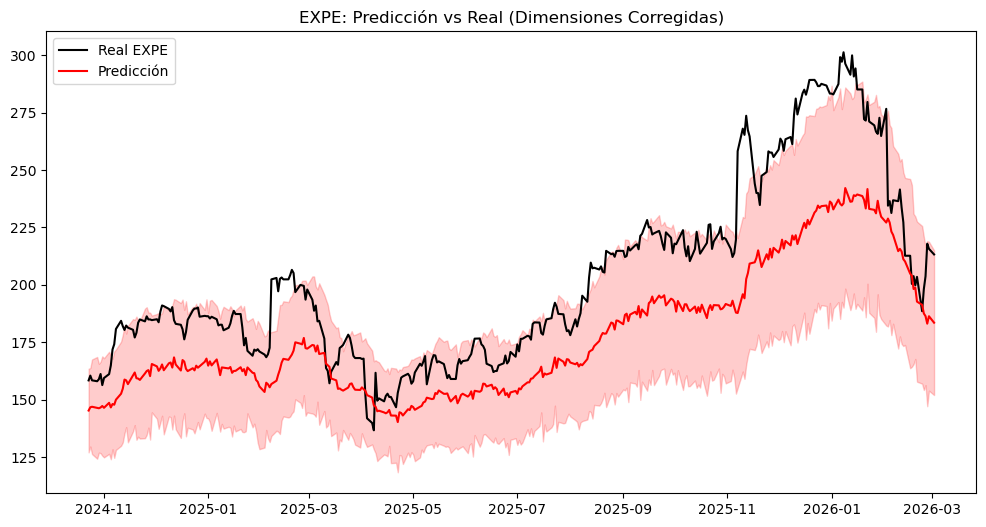

In [49]:
plt.figure(figsize=(12, 6))
plt.plot(test_index_ajustado, y_test_usd, label="Real EXPE", color="black")
plt.plot(test_index_ajustado, mean_preds_usd, label="Predicción", color="red")
plt.fill_between(test_index_ajustado, lower_bound, upper_bound, color="red", alpha=0.2)
plt.title("EXPE: Predicción vs Real (Dimensiones Corregidas)")
plt.legend()
plt.show()

In [32]:
%reset

Once deleted, variables cannot be recovered. Proceed (y/[n])?  n


Nothing done.
